# Task 3: Deep-Dive Analysis & Interactive Dashboard

## 1. Core KPIs Definition

Based on business requirements, the following key performance indicators (KPIs) are defined:

1. Total Revenue = Sum of total_revenue  
2. Total Orders = Count of order_id  
3. Average Order Value (AOV) = Total Revenue / Total Orders  
4. Average Delivery Time = Mean of delivery_days  
5. Late Delivery Rate (%) = Percentage of orders where delivery_delay > 0  

These KPIs help evaluate sales performance, delivery efficiency, and customer experience.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("cleaned_master_olist_dataset.csv")

df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_year,purchase_month,...,delivery_days,estimated_delivery_days,delivery_delay,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,total_revenue
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,...,8.0,15,-7.0,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,...,13.0,19,-6.0,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,...,9.0,26,-17.0,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,11,...,13.0,26,-13.0,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2,...,2.0,12,-10.0,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,28.62


In [3]:
# KPI Calculations

total_revenue = df['total_revenue'].sum()
total_orders = df['order_id'].nunique()
avg_order_value = total_revenue / total_orders
avg_delivery_time = df['delivery_days'].mean()
late_delivery_rate = (df['delivery_delay'] > 0).mean() * 100

print("Total Revenue:", total_revenue)
print("Total Orders:", total_orders)
print("Average Order Value:", avg_order_value)
print("Average Delivery Time:", avg_delivery_time)
print("Late Delivery Rate (%):", late_delivery_rate)

Total Revenue: 15843553.239999998
Total Orders: 98666
Average Order Value: 160.57763809214924
Average Delivery Time: 12.007722603361284
Late Delivery Rate (%): 7.232134931202841


## 2. Deep Dive Analysis: Customer Segmentation

To better understand business performance, we segment orders based on total revenue.

We divide orders into 3 categories:
- Low Value Orders
- Medium Value Orders
- High Value Orders

This helps identify revenue distribution and customer spending behavior.

In [4]:
# Create Revenue Segments

df['revenue_segment'] = pd.qcut(
    df['total_revenue'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

df[['total_revenue', 'revenue_segment']].head()

,total_revenue,revenue_segment
0,38.71,Low
1,141.46,High
2,179.12,High
3,72.20,Medium
4,28.62,Low


In [5]:
# Count of each segment

segment_counts = df['revenue_segment'].value_counts()
print(segment_counts)

revenue_segment
Medium    37557
Low       37552
High      37541
Name: count, dtype: int64


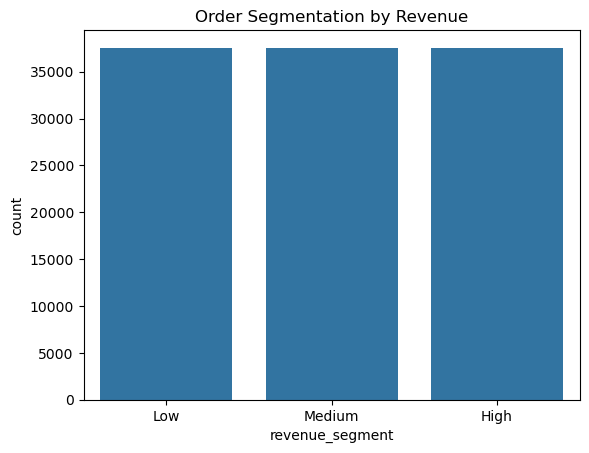

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='revenue_segment', data=df)
plt.title("Order Segmentation by Revenue")
plt.show()

In [7]:
df.to_csv("cleaned_master_final.csv", index=False)